# 02 · Filtrado fino y split público / privado

Este notebook toma la salida del **01_preprocesamiento_denue.ipynb** (`salud_cdmx_denue_limpio.csv`) y la refina para el análisis topológico:

1. **Filtro SCIAN estricto** — infraestructura médica de primer nivel: consultorios médicos, dentales, de otros profesionales (psicólogos, optometristas, nutriólogos), centros ambulatorios, laboratorios y hospitales. Se excluyen residencias para adultos mayores, AA, guarderías y comunidades terapéuticas.
2. **Split público vs privado** — usando *string matching* sobre `nombre_act`.
3. **Reproyección a UTM 14N (EPSG:32614)** — para que las distancias estén en metros y los radios del Vietoris-Rips sean interpretables ("este hueco mide 800 m ≈ 10 min caminando").
4. **Colapso de duplicados de coordenadas** — puntos en la misma (x, y) son ubicaciones reales (torres médicas, plazas, hospitales con servicios registrados por separado). Como nuestro análisis busca **huecos de cobertura geográfica**, lo que importa es la ubicación, no cuántos servicios hay en cada una. Fusionamos los puntos coincidentes en uno y guardamos la multiplicidad en `n_servicios` para análisis complementarios.
5. **Outliers geográficos** — recorte al bounding box de CDMX.

**Salidas:**
- `../data/processed/salud_cdmx_publico.csv`
- `../data/processed/salud_cdmx_privado.csv`

Cada fila representa una **ubicación geográfica única** con N servicios médicos asociados.

In [36]:
# Si no las tienen instaladas:
# pip install geopandas pyproj

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
import zipfile

import geopandas as gpd

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargar el CSV procesado del notebook 01

Esta celda hace el notebook autosuficiente: descarga el zip y regenera el CSV procesado si no existen.

In [38]:
# Rutas
DATA_RAW_DIR = "../data/raw"
DATA_PROC_DIR = "../data/processed"
ZIP_PATH = os.path.join(DATA_RAW_DIR, "denue_09_csv.zip")
PROCESSED_CSV = os.path.join(DATA_PROC_DIR, "salud_cdmx_denue_limpio.csv")

DENUE_ZIP_URL = (
    "https://cfcetlsadls.blob.core.windows.net/raw/inegi/denue_por_estado/"
    "ciudad_de_mexico_zip/denue_09_csv.zip"
    "?sv=2025-07-05&spr=https&st=2026-04-24T19%3A24%3A46Z"
    "&se=2026-06-09T19%3A24%3A00Z&sr=b&sp=r"
    "&sig=%2F5%2BqqFCki1Y%2Bdl3Y21slq3HOd7Ek5cDjh849JlR37Dc%3D"
)

os.makedirs(DATA_RAW_DIR, exist_ok=True)
os.makedirs(DATA_PROC_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    print("Descargando DENUE CDMX (puede tomar 1-2 min)...")
    urllib.request.urlretrieve(DENUE_ZIP_URL, ZIP_PATH)
    print(f"  -> {ZIP_PATH} ({os.path.getsize(ZIP_PATH)/1e6:.1f} MB)")
else:
    print(f"OK: zip ya existe en {ZIP_PATH}")

if not os.path.exists(PROCESSED_CSV):
    print("\nRegenerando CSV procesado desde el zip (lógica del notebook 01)...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        df_raw = pd.read_csv(
            z.open("conjunto_de_datos/denue_inegi_09_.csv"),
            encoding="latin1",
            low_memory=False,
        )
    df_tmp = df_raw[df_raw["codigo_act"].astype(str).str.startswith("62")].copy()
    df_tmp["latitud"] = pd.to_numeric(df_tmp["latitud"], errors="coerce")
    df_tmp["longitud"] = pd.to_numeric(df_tmp["longitud"], errors="coerce")
    df_tmp = df_tmp.dropna(subset=["latitud", "longitud"])
    cols = ["id", "nom_estab", "codigo_act", "nombre_act", "per_ocu",
            "municipio", "localidad", "latitud", "longitud", "fecha_alta"]
    df_tmp[cols].to_csv(PROCESSED_CSV, index=False)
    print(f"  -> {PROCESSED_CSV} ({len(df_tmp):,} filas)")
else:
    print(f"OK: CSV procesado ya existe en {PROCESSED_CSV}")

OK: zip ya existe en ../data/raw/denue_09_csv.zip
OK: CSV procesado ya existe en ../data/processed/salud_cdmx_denue_limpio.csv


In [39]:
df = pd.read_csv(PROCESSED_CSV)
print(f"Establecimientos del sector salud (62 completo): {len(df):,}")
df.head()

Establecimientos del sector salud (62 completo): 22,841


,id,nom_estab,codigo_act,nombre_act,per_ocu,municipio,localidad,latitud,longitud,fecha_alta
0,11822253,MARIE STOPES CONDESA,621411,Centros de planificación familiar del sector p...,11 a 30 personas,Cuauhtémoc,Cuauhtémoc ...,19.415518,-99.172861,2025-04
1,6795800,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,Xochimilco,Xochimilco ...,19.280340,-99.137950,2017-03
2,8485187,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Cuauhtémoc,Cuauhtémoc ...,19.460542,-99.131678,2019-11
3,767683,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Gustavo A. Madero,Gustavo A. Madero ...,19.492214,-99.087259,2010-07
4,11366041,20 DENTAL,621211,Consultorios dentales del sector privado,0 a 5 personas,Venustiano Carranza,Venustiano Carranza ...,19.440626,-99.107722,2024-11


## Paso 1 · Filtro SCIAN estricto

Del sector 62 nos quedamos con las sub-ramas que corresponden a infraestructura médica real:

| Sub-rama | Códigos | Qué incluye |
|---|---|---|
| Consultorios médicos | `6211**` | Medicina general y especializada |
| Consultorios dentales | `6212**` | Odontología en todas sus formas |
| Consultorios de otros profesionales | `6213**` | Psicólogos, optometristas, nutriólogos, quiroprácticos |
| Centros ambulatorios | `6214**` | Planificación familiar, atención sin hospitalización |
| Laboratorios y diagnóstico | `6215**` | Laboratorios clínicos, imagenología |
| Hospitales | `6221**`, `6222**`, `6223**` | Generales, psiquiátricos, otras especialidades |

**Se excluyen:** `6231–6239` (residencias para adultos mayores y con discapacidad), `6241–6244` (AA, comedores comunitarios, guarderías). No constituyen "atención médica" para efectos de cobertura.

In [40]:
# Diagnóstico: distribución por prefijo de 4 dígitos
df["codigo_4d"] = df["codigo_act"].astype(str).str[:4]
print("Distribución por prefijo de 4 dígitos:")
print(df["codigo_4d"].value_counts().sort_index())

Distribución por prefijo de 4 dígitos:
codigo_4d
6211    6638
6212    7334
6213    4025
6214     141
6215     797
6216       8
6219      23
6221     257
6222      14
6223     102
6231      16
6232      79
6233     109
6239     124
6241    2089
6242     482
6243      22
6244     581
Name: count, dtype: int64


In [41]:
# Aplicar filtro estricto
prefijos_validos = ["6211", "6212", "6213", "6214", "6215", "6221", "6222", "6223"]

df_estricto = df[df["codigo_4d"].isin(prefijos_validos)].copy()

print(f"Antes (sector 62 completo): {len(df):,}")
print(f"Después (infraestructura médica real): {len(df_estricto):,}")
print(f"Reducción: {len(df) - len(df_estricto):,} establecimientos eliminados\n")

# Etiqueta de tipo
mapa_tipo = {
    "6211": "Consultorio médico",
    "6212": "Consultorio dental",
    "6213": "Consultorio otros profesionales",
    "6214": "Centro ambulatorio",
    "6215": "Laboratorio/Dx",
    "6221": "Hospital general",
    "6222": "Hospital psiquiátrico",
    "6223": "Hospital especializado",
}
df_estricto["tipo_infra"] = df_estricto["codigo_4d"].map(mapa_tipo)

print("Composición de la nube médica:")
print(df_estricto["tipo_infra"].value_counts())

Antes (sector 62 completo): 22,841
Después (infraestructura médica real): 19,308
Reducción: 3,533 establecimientos eliminados

Composición de la nube médica:
tipo_infra
Consultorio dental                 7334
Consultorio médico                 6638
Consultorio otros profesionales    4025
Laboratorio/Dx                      797
Hospital general                    257
Centro ambulatorio                  141
Hospital especializado              102
Hospital psiquiátrico                14
Name: count, dtype: int64


## Paso 2 · Split público vs privado

El SCIAN 2018 codifica la distinción en el **texto** de `nombre_act` (no de forma uniforme en los dígitos), así que hacemos string matching sobre las frases canónicas *"sector público"* y *"sector privado"*.

In [42]:
nombre_lower = df_estricto["nombre_act"].str.lower().fillna("")
es_publico = nombre_lower.str.contains("sector público")
es_privado = nombre_lower.str.contains("sector privado")

df_estricto["sector"] = np.select(
    [es_publico, es_privado],
    ["publico", "privado"],
    default="otro"
)

print("Distribución por sector:")
print(df_estricto["sector"].value_counts())
print()
print("Proporción:")
print((df_estricto["sector"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Distribución por sector:
sector
privado    17990
publico      681
otro         637
Name: count, dtype: int64

Proporción:
sector
privado    93.17 %
publico     3.53 %
otro         3.3 %
Name: proportion, dtype: object


In [43]:
# ¿Hay actividades sin sector clasificado? Revisar antes de descartar
otros = df_estricto[df_estricto["sector"] == "otro"]
print(f"Establecimientos en categoría 'otro': {len(otros)}")
if len(otros) > 0:
    print("\nActividades en 'otro':")
    print(otros["nombre_act"].value_counts().head(20))

Establecimientos en categoría 'otro': 637

Actividades en 'otro':
nombre_act
Consultorios de optometría    637
Name: count, dtype: int64


In [44]:
# Descartar 'otro' (sin sector identificable)
df_estricto = df_estricto[df_estricto["sector"].isin(["publico", "privado"])].copy()

print(f"Establecimientos finales (público + privado): {len(df_estricto):,}\n")
print("Cruce sector × tipo de infraestructura:")
print(df_estricto.groupby(["sector", "tipo_infra"]).size().unstack(fill_value=0))

Establecimientos finales (público + privado): 18,671

Cruce sector × tipo de infraestructura:
tipo_infra  Centro ambulatorio  Consultorio dental  Consultorio médico  \
sector                                                                   
privado                    119                7287                6227   
publico                     22                  47                 411   

tipo_infra  Consultorio otros profesionales  Hospital especializado  \
sector                                                                
privado                                3338                      80   
publico                                  50                      22   

tipo_infra  Hospital general  Hospital psiquiátrico  Laboratorio/Dx  
sector                                                               
privado                  139                      9             791  
publico                  118                      5               6  


## Paso 3 · Reproyección a UTM 14N (EPSG:32614)

Las coordenadas en grados (lat/lon) no son métricas: 1° de latitud ≈ 111 km, pero 1° de longitud en CDMX ≈ 105 km (depende del cos(latitud)). Si calculamos distancias euclidianas sobre lat/lon, el complejo de Vietoris-Rips queda **deformado**.

Reproyectamos a UTM zona 14N — el sistema métrico estándar para el centro de México — para que las distancias estén en **metros**.

In [45]:
gdf = gpd.GeoDataFrame(
    df_estricto,
    geometry=gpd.points_from_xy(df_estricto["longitud"], df_estricto["latitud"]),
    crs="EPSG:4326"
).to_crs("EPSG:32614")

df_estricto["x_m"] = gdf.geometry.x.values
df_estricto["y_m"] = gdf.geometry.y.values

print("Rango en metros (UTM 14N):")
print(df_estricto[["x_m", "y_m"]].describe().round(1))
print(f"\nExtensión x: {df_estricto['x_m'].max() - df_estricto['x_m'].min():.0f} m")
print(f"Extensión y: {df_estricto['y_m'].max() - df_estricto['y_m'].min():.0f} m")

Rango en metros (UTM 14N):
            x_m        y_m
count   18671.0    18671.0
mean   485231.1  2142966.4
std      6542.5     7844.9
min    464954.8  2115977.3
25%    481325.1  2137319.5
50%    484046.5  2143256.9
75%    489308.4  2148180.9
max    505109.2  2164907.1

Extensión x: 40154 m
Extensión y: 48930 m


## Paso 4 · Colapso de duplicados de coordenadas

Muchos establecimientos comparten la misma (x, y): torres médicas, plazas con múltiples consultorios, hospitales con servicios registrados por separado, geocodificado al nivel de manzana. **Estos no son errores** — reflejan que en una misma ubicación geográfica hay múltiples servicios.

Para el análisis de **huecos de cobertura**, lo que importa es la ubicación, no la cantidad. Colapsamos puntos coincidentes en una sola fila y guardamos:
- `n_servicios`: cuántos establecimientos hay en esa ubicación
- `tipos_presentes`: qué categorías de infraestructura coexisten ahí

El colapso se hace **por sector**, así que el público y el privado se procesan independientemente.

In [46]:
# Diagnóstico previo
print("Antes del colapso:")
for s in ["publico", "privado"]:
    sub = df_estricto[df_estricto["sector"] == s]
    unicos = sub.drop_duplicates(subset=["x_m", "y_m"]).shape[0]
    dups = len(sub) - unicos
    print(f"  {s}: {len(sub):,} establecimientos en {unicos:,} ubicaciones únicas "
          f"({dups:,} colapsarán, {100*dups/len(sub):.1f} %)")

Antes del colapso:
  publico: 681 establecimientos en 659 ubicaciones únicas (22 colapsarán, 3.2 %)
  privado: 17,990 establecimientos en 13,043 ubicaciones únicas (4,947 colapsarán, 27.5 %)


In [47]:
def colapsar_por_ubicacion(df_in):
    """Agrupa establecimientos que comparten (x_m, y_m) en una sola fila.

    Conserva:
    - n_servicios: multiplicidad
    - tipos_presentes: lista de tipos de infraestructura en esa ubicación
    - tipo_infra: el tipo más frecuente en esa ubicación (representante)
    - id, nom_estab, etc.: primer valor del grupo (representativo)
    """
    def tipo_mas_frecuente(s):
        return s.value_counts().index[0]

    def tipos_unicos(s):
        return ", ".join(sorted(s.unique()))

    agg = (df_in
           .groupby(["x_m", "y_m"], as_index=False, sort=False)
           .agg(
               n_servicios   = ("id", "size"),
               id            = ("id", "first"),
               nom_estab     = ("nom_estab", "first"),
               codigo_act    = ("codigo_act", "first"),
               nombre_act    = ("nombre_act", "first"),
               tipo_infra    = ("tipo_infra", tipo_mas_frecuente),
               tipos_presentes = ("tipo_infra", tipos_unicos),
               sector        = ("sector", "first"),
               per_ocu       = ("per_ocu", "first"),
               municipio     = ("municipio", "first"),
               localidad     = ("localidad", "first"),
               latitud       = ("latitud", "first"),
               longitud      = ("longitud", "first"),
               fecha_alta    = ("fecha_alta", "first"),
           ))
    return agg

# Colapsar cada sector por separado
df_pub  = colapsar_por_ubicacion(df_estricto[df_estricto["sector"] == "publico"])
df_priv = colapsar_por_ubicacion(df_estricto[df_estricto["sector"] == "privado"])

print("Después del colapso:")
print(f"  publico: {len(df_pub):,} ubicaciones únicas (n_servicios suma {df_pub['n_servicios'].sum():,})")
print(f"  privado: {len(df_priv):,} ubicaciones únicas (n_servicios suma {df_priv['n_servicios'].sum():,})")

Después del colapso:
  publico: 659 ubicaciones únicas (n_servicios suma 681)
  privado: 13,043 ubicaciones únicas (n_servicios suma 17,990)


In [48]:
# Distribución de n_servicios por ubicación: ¿qué tan concentrado está?
print("Distribución de servicios por ubicación (privado):")
print(df_priv["n_servicios"].describe().round(2))
print("\nUbicaciones con más servicios (privado, top 10):")
print(df_priv.nlargest(10, "n_servicios")[
    ["nom_estab", "municipio", "n_servicios", "tipos_presentes"]
].to_string(index=False))

Distribución de servicios por ubicación (privado):
count    13043.00
mean         1.38
std          5.03
min          1.00
25%          1.00
50%          1.00
75%          1.00
max        282.00
Name: n_servicios, dtype: float64

Ubicaciones con más servicios (privado, top 10):
                          nom_estab              municipio  n_servicios                                                                                                    tipos_presentes
 ANDRES FELIPE COBALEDA ARISTIZABAL             Cuauhtémoc          282        Centro ambulatorio, Consultorio dental, Consultorio médico, Consultorio otros profesionales, Laboratorio/Dx
                        ALERGOLOGIA                Tlalpan          233                            Consultorio dental, Consultorio médico, Consultorio otros profesionales, Laboratorio/Dx
                    CIRUGIA GENERAL         Álvaro Obregón          217                              Consultorio médico, Consultorio otros profesionales, Hospit

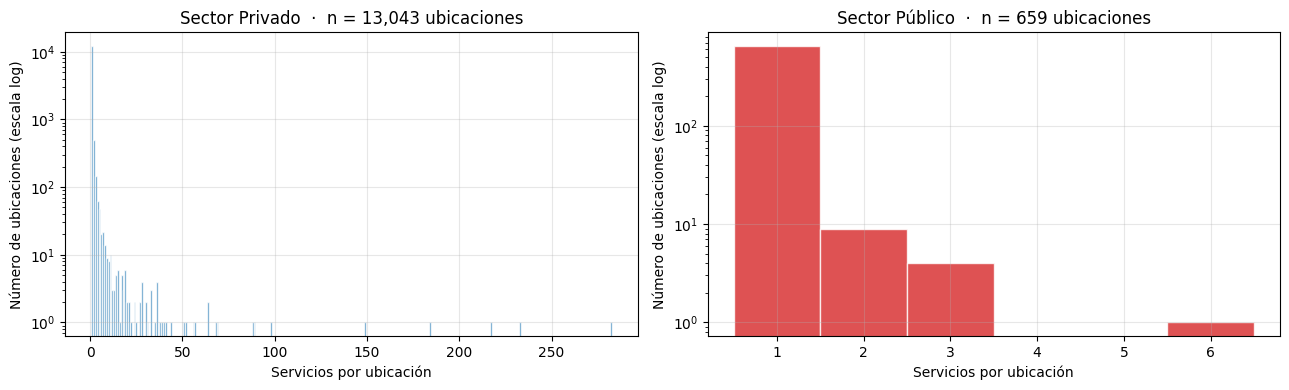

In [49]:
# Histograma de multiplicidad para visualizar la concentración
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (sub, nombre, color) in zip(
    axes,
    [(df_priv, "Privado", "#1f77b4"), (df_pub, "Público", "#d62728")]
):
    bins = np.arange(0.5, sub["n_servicios"].max() + 1.5, 1)
    ax.hist(sub["n_servicios"], bins=bins, color=color, alpha=0.8, edgecolor="white")
    ax.set_yscale("log")
    ax.set_xlabel("Servicios por ubicación")
    ax.set_ylabel("Número de ubicaciones (escala log)")
    ax.set_title(f"Sector {nombre}  ·  n = {len(sub):,} ubicaciones")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 5 · Outliers geográficos

Recortamos al bounding box de CDMX para descartar puntos con coordenadas mal capturadas (≈ 19.05–19.60° N, −99.40 a −98.94° E).

In [50]:
LAT_MIN, LAT_MAX = 19.05, 19.60
LON_MIN, LON_MAX = -99.40, -98.94

def filtrar_bb(df_in):
    dentro = (
        df_in["latitud"].between(LAT_MIN, LAT_MAX) &
        df_in["longitud"].between(LON_MIN, LON_MAX)
    )
    fuera = (~dentro).sum()
    return df_in[dentro].copy(), fuera

df_pub,  fuera_pub  = filtrar_bb(df_pub)
df_priv, fuera_priv = filtrar_bb(df_priv)

print(f"Outliers descartados: público = {fuera_pub}, privado = {fuera_priv}")
print(f"\nUbicaciones finales:")
print(f"  publico: {len(df_pub):,}")
print(f"  privado: {len(df_priv):,}")

Outliers descartados: público = 0, privado = 0

Ubicaciones finales:
  publico: 659
  privado: 13,043


## Visualización: público vs privado lado a lado

El tamaño del marcador escala con `n_servicios` para que las torres médicas y plazas se vean como puntos grandes.

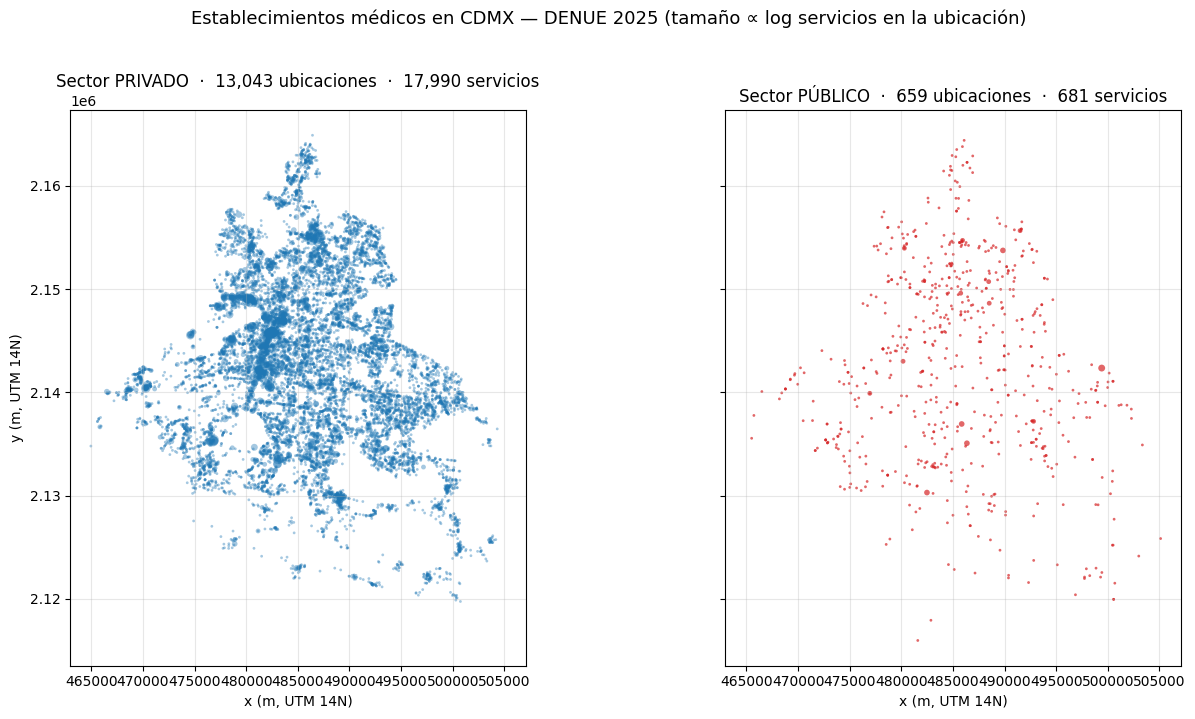

In [51]:
def marker_size(n, base=4, scale=8):
    """Tamaño de marcador proporcional a log2(n_servicios)."""
    return base + scale * np.log2(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# Panel 1: Privado
axes[0].scatter(
    df_priv["x_m"], df_priv["y_m"],
    s=marker_size(df_priv["n_servicios"]),
    alpha=0.4, color="#1f77b4", edgecolors="none"
)
axes[0].set_title(f"Sector PRIVADO  ·  {len(df_priv):,} ubicaciones  ·  "
                  f"{df_priv['n_servicios'].sum():,} servicios")
axes[0].set_xlabel("x (m, UTM 14N)")
axes[0].set_ylabel("y (m, UTM 14N)")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.3)

# Panel 2: Público
axes[1].scatter(
    df_pub["x_m"], df_pub["y_m"],
    s=marker_size(df_pub["n_servicios"]),
    alpha=0.7, color="#d62728", edgecolors="none"
)
axes[1].set_title(f"Sector PÚBLICO  ·  {len(df_pub):,} ubicaciones  ·  "
                  f"{df_pub['n_servicios'].sum():,} servicios")
axes[1].set_xlabel("x (m, UTM 14N)")
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.3)

plt.suptitle("Establecimientos médicos en CDMX — DENUE 2025 (tamaño ∝ log servicios en la ubicación)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

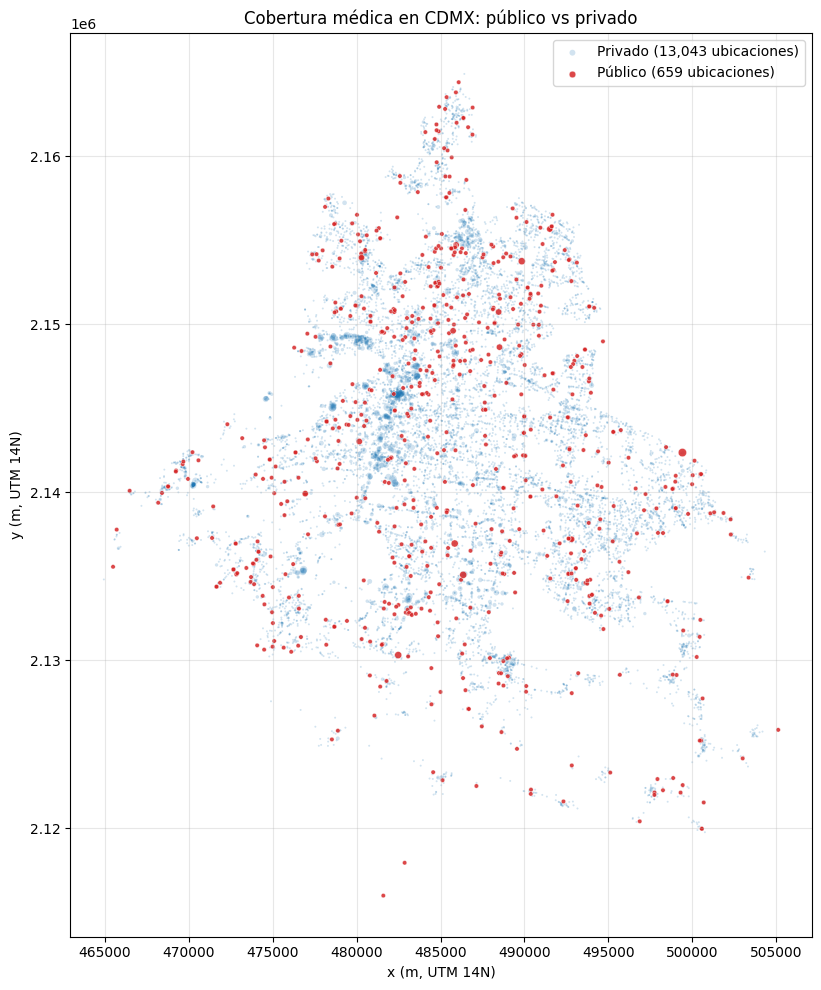

In [52]:
# Overlay: privado de fondo, público encima
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    df_priv["x_m"], df_priv["y_m"],
    s=marker_size(df_priv["n_servicios"], base=2, scale=4),
    alpha=0.20, color="#1f77b4", edgecolors="none",
    label=f"Privado ({len(df_priv):,} ubicaciones)"
)
ax.scatter(
    df_pub["x_m"], df_pub["y_m"],
    s=marker_size(df_pub["n_servicios"], base=10, scale=10),
    alpha=0.85, color="#d62728", edgecolors="white", linewidth=0.3,
    label=f"Público ({len(df_pub):,} ubicaciones)"
)

ax.set_xlabel("x (m, UTM 14N)")
ax.set_ylabel("y (m, UTM 14N)")
ax.set_title("Cobertura médica en CDMX: público vs privado")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Guardar las dos nubes de puntos

In [53]:
os.makedirs(DATA_PROC_DIR, exist_ok=True)

cols_finales = [
    "id", "nom_estab", "codigo_act", "nombre_act",
    "tipo_infra", "tipos_presentes", "n_servicios",
    "sector", "per_ocu", "municipio", "localidad",
    "latitud", "longitud", "x_m", "y_m", "fecha_alta"
]

df_pub[cols_finales].to_csv(os.path.join(DATA_PROC_DIR, "salud_cdmx_publico.csv"), index=False)
df_priv[cols_finales].to_csv(os.path.join(DATA_PROC_DIR, "salud_cdmx_privado.csv"), index=False)

print("Archivos guardados:")
print(f"  {DATA_PROC_DIR}/salud_cdmx_publico.csv  ({len(df_pub):,} ubicaciones)")
print(f"  {DATA_PROC_DIR}/salud_cdmx_privado.csv  ({len(df_priv):,} ubicaciones)")

Archivos guardados:
  ../data/processed/salud_cdmx_publico.csv  (659 ubicaciones)
  ../data/processed/salud_cdmx_privado.csv  (13,043 ubicaciones)


## Resumen y siguientes pasos

**Lo que tenemos al cerrar este notebook:**
- Dos nubes de puntos de **ubicaciones únicas** (no establecimientos individuales).
- Coordenadas en metros (UTM 14N), listas para Vietoris-Rips o Alpha complex.
- Columna `n_servicios` con la multiplicidad para análisis complementarios y para ponderar huecos por contexto.
- Etiquetas `tipo_infra` y `tipos_presentes` para análisis estratificado.

**Notebook 03 · Complejos simpliciales (siguiente):**
- Construir Alpha complex (más eficiente que Vietoris-Rips en 2D) para cada nube por separado.
- Calcular persistencia hasta H₁ (huecos / agujeros).
- Generar los diagramas de persistencia comparativos público vs privado.
- Identificar los huecos más persistentes y mapearlos sobre CDMX.